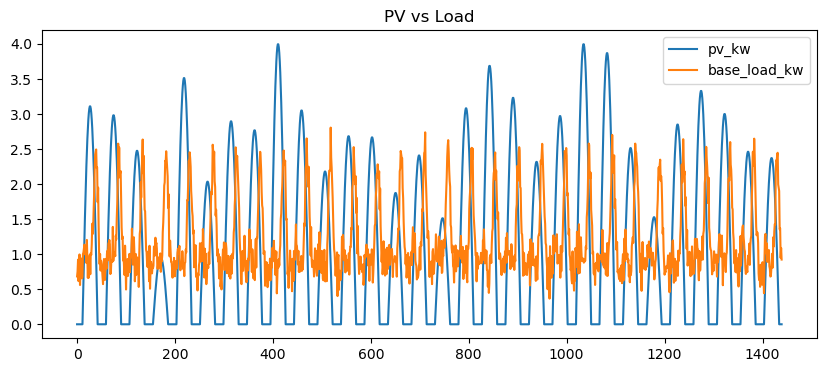

In [248]:
import pandas as pd

df = pd.read_csv("caseA_smart_home_30min_summer.csv")

df.head(1440)

dt= 0.5 #hours
df['pv_kwh'] = df['pv_kw'] * dt
df['load_kwh'] = df['base_load_kw'] * dt

import matplotlib.pyplot as plt

df[['pv_kw', 'base_load_kw']].plot(figsize=(10,4))
plt.title("PV vs Load")
plt.show()

# Extract key variables

pv = df['pv_kwh'].values
load = df['load_kwh'].values
price_import = df['import_tariff_gbp_per_kwh'].values
price_export = df['export_price_gbp_per_kwh'].values

In [249]:
# Battery parameters
battery_capacity = 5.0      # kWh
soc_init = 2.5               # kWh
soc_min = 0.5               # kWh
soc_max = battery_capacity   # kWh

p_charge_max = 2.5           # kW
p_discharge_max = 2.5      # kW

eta_charge = 0.95
eta_discharge = 0.95

# Convert power limits to energy per timestep
e_charge_max = p_charge_max * dt
e_discharge_max = p_discharge_max * dt


In [250]:
import numpy as np

n = len(df)

soc = np.zeros(n + 1)
soc[0] = soc_init

charge = np.zeros(n)         # kWh charged into battery each timestep
discharge = np.zeros(n)      # kWh discharged from battery each timestep
grid_import = np.zeros(n)    # kWh imported from grid
grid_export = np.zeros(n)    # kWh exported to grid
pv_to_load = np.zeros(n)     # kWh from PV directly to load
# =========================
# BASELINE (NO BATTERY)
# =========================

baseline_import = np.maximum(load - pv, 0)
baseline_export = np.maximum(pv - load, 0)

In [251]:
#Policy 1: Self-Consumption Policy
battery_life = np.zeros(n + 1)
battery_life[0] = 100.0
k_deg = 0.01   # life points lost per kWh throughput
c_deg = 0.02   # £ per kWh throughput

for t in range(n):
    pv_available = pv[t]
    load_needed = load[t]

    # 1. PV serves load first
    pv_to_load[t] = min(pv_available, load_needed)
    pv_surplus = pv_available - pv_to_load[t]
    load_remaining = load_needed - pv_to_load[t]
    effective_capacity = battery_capacity * (battery_life[t] / 100.0)
    
    # 2. Charge battery with surplus PV
    battery_room = effective_capacity - soc[t]
    max_charge_possible = min(e_charge_max, battery_room / eta_charge)
    charge[t] = min(pv_surplus, max_charge_possible)

    soc_after_charge = soc[t] + eta_charge * charge[t]
    pv_surplus_after_charge = pv_surplus - charge[t]

    # 3. Export any remaining PV surplus
    grid_export[t] = pv_surplus_after_charge
    
    # 4. On the last day, protect enough SOC to end at soc_init
    if t >= n - 48:
        effective_soc_min = soc_init
    else:
        effective_soc_min = soc_min

    battery_available = soc_after_charge - effective_soc_min
    battery_available = max(battery_available, 0)
    
    max_discharge_possible = min(e_discharge_max, battery_available * eta_discharge)
    discharge[t] = min(load_remaining, max_discharge_possible)

    soc[t + 1] = soc_after_charge - discharge[t] / eta_discharge
    throughput = charge[t] + discharge[t]
    battery_life[t + 1] = max(0.0, battery_life[t] - k_deg * throughput)

    # 5. Import any remaining unmet load
    load_after_discharge = load_remaining - discharge[t]
    grid_import[t] = load_after_discharge
    
soc_shortfall = soc_init - soc[-1]
if soc_shortfall > 1e-6:
    avg_tariff = price_import.mean()
    soc_penalty = soc_shortfall * avg_tariff / eta_charge
    print(f'SOC shortfall: {soc_shortfall:.4f} kWh → penalty: £{soc_penalty:.4f}')
else:
    soc_penalty = 0.0
    print(f'No SOC shortfall (final SOC = {soc[-1]:.4f})')
    
import_cost = np.sum(grid_import * price_import)
export_revenue = np.sum(grid_export * price_export)
net_cost = import_cost - export_revenue

deg_cost1 = c_deg * np.sum(charge + discharge)
net_cost_deg1 = net_cost + deg_cost1

No SOC shortfall (final SOC = 2.5000)


In [252]:
print("Final SOC:", soc[-1])
print("Initial SOC:", soc_init)
print("Total grid import (kWh):", grid_import.sum())
print("Total grid export (kWh):", grid_export.sum())
print("Policy 1 degradation cost (£):", deg_cost1)
print("Policy 1 net cost WITH degradation (£):", net_cost_deg1)

Final SOC: 2.5
Initial SOC: 2.5
Total grid import (kWh): 299.93806927997264
Total grid export (kWh): 242.12259255398632
Policy 1 degradation cost (£): 5.036054763320821
Policy 1 net cost WITH degradation (£): 34.27403059555675


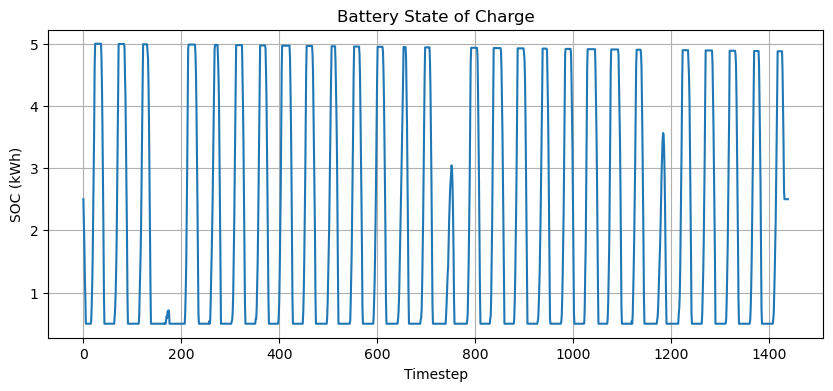

In [253]:
plt.figure(figsize=(10,4))
plt.plot(soc[:-1])
plt.title("Battery State of Charge")
plt.ylabel("SOC (kWh)")
plt.xlabel("Timestep")
plt.grid(True)
plt.show()

In [254]:
print("SOC min:", soc.min())
print("SOC max:", soc.max())

print("Any negative grid import?", (grid_import < -1e-9).any())
print("Any negative grid export?", (grid_export < -1e-9).any())
print("Any negative charge?", (charge < -1e-9).any())
print("Any negative discharge?", (discharge < -1e-9).any())

SOC min: 0.5
SOC max: 4.996881125
Any negative grid import? False
Any negative grid export? False
Any negative charge? True
Any negative discharge? False


In [255]:
balance_error = pv - (pv_to_load + charge + grid_export)
load_error = load - (pv_to_load + discharge + grid_import)

print("Max PV-side balance error:", abs(balance_error).max())
print("Max load-side balance error:", abs(load_error).max())


Max PV-side balance error: 2.220446049250313e-16
Max load-side balance error: 1.1102230246251565e-16


In [256]:
# Check: no simultaneous charge and discharge
simul = ((charge > 1e-10) & (discharge > 1e-10)).sum()
print("Simultaneous ch/dis violations:", simul)

# Check: SOC dynamics (recompute independently)
soc_check = np.zeros(n + 1)
soc_check[0] = soc_init
for t in range(n):
    soc_check[t+1] = soc_check[t] + eta_charge * charge[t] - discharge[t] / eta_discharge
print("SOC recompute drift:", np.abs(soc_check - soc).max())

# Check: global energy conservation
total_in = pv.sum() + grid_import.sum()
total_out = load.sum() + grid_export.sum()
delta_soc = soc[-1] - soc[0]
losses = charge.sum() * (1 - eta_charge) + discharge.sum() * (1/eta_discharge - 1)
cons_err = abs(total_in - total_out - delta_soc - losses)
print("Conservation error:", cons_err, "kWh")

# Unit check (worked example, step t=14)
t_ex = 14
print(f"\nUnit check (t={t_ex}):")
print(f"  {grid_import[t_ex]/dt:.4f} kW × {dt} h = {grid_import[t_ex]:.4f} kWh")
print(f"  {grid_import[t_ex]:.4f} kWh × {price_import[t_ex]:.4f} £/kWh = £{grid_import[t_ex]*price_import[t_ex]:.6f}")

Simultaneous ch/dis violations: 0
SOC recompute drift: 0.0
Conservation error: 1.0658141036401503e-14 kWh

Unit check (t=14):
  0.1459 kW × 0.5 h = 0.0730 kWh
  0.0730 kWh × 0.1146 £/kWh = £0.008360


In [257]:
import_cost = np.sum(grid_import * price_import)
export_revenue = np.sum(grid_export * price_export)
net_cost = import_cost - export_revenue

print("Import cost (£):", import_cost)
print("Export revenue (£):", export_revenue)
print("Net cost (£):", net_cost)

Import cost (£): 41.34043839897305
Export revenue (£): 12.102462566737119
Net cost (£): 29.237975832235932


In [258]:
baseline_grid_import = np.maximum(load - pv, 0)
baseline_grid_export = np.maximum(pv - load, 0)

baseline_import_cost = np.sum(baseline_grid_import * price_import)
baseline_export_revenue = np.sum(baseline_grid_export * price_export)
baseline_net_cost = baseline_import_cost - baseline_export_revenue

print("Baseline import cost (£):", baseline_import_cost)
print("Baseline export revenue (£):", baseline_export_revenue)
print("Baseline net cost (£):", baseline_net_cost)

Baseline import cost (£): 78.958279825
Baseline export revenue (£): 18.70480698
Baseline net cost (£): 60.253472845000005


In [259]:
print("Battery case net cost (£):", net_cost)
print("Savings vs baseline (£):", baseline_net_cost - net_cost)

Battery case net cost (£): 29.237975832235932
Savings vs baseline (£): 31.015497012764072


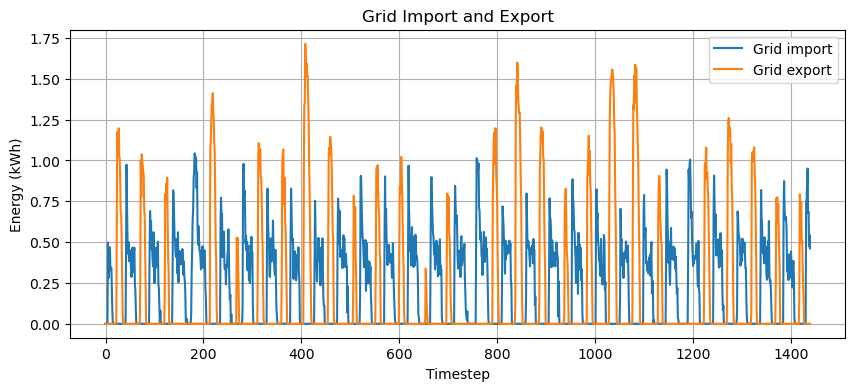

In [260]:
plt.figure(figsize=(10,4))
plt.plot(grid_import, label="Grid import")
plt.plot(grid_export, label="Grid export")
plt.title("Grid Import and Export")
plt.xlabel("Timestep")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.show()

In [261]:
pv_total = pv.sum()
load_total = load.sum()

pv_used_locally = pv_to_load.sum() + charge.sum()
self_consumption_ratio = pv_used_locally / pv_total

print("Total PV generation (kWh):", pv_total)
print("Total load (kWh):", load_total)
print("PV used locally (kWh):", pv_used_locally)
print("Self-consumption ratio:", self_consumption_ratio)


Total PV generation (kWh): 812.4226
Total load (kWh): 857.3335999999999
PV used locally (kWh): 570.3000074460138
Self-consumption ratio: 0.7019745726497685


In [262]:
self_sufficiency_ratio = 1 - grid_import.sum() / load_total
print("Self-sufficiency ratio:", self_sufficiency_ratio)


Self-sufficiency ratio: 0.6501501057698279


In [263]:
# Policy 2: tariff-aware discharge

battery_life2 = np.zeros(n + 1)
battery_life2[0] = 100.0

price_threshold = 0.20  # £/kWh — sits between the 12p and 34p clusters

soc2 = np.zeros(n + 1)
soc2[0] = soc_init

charge2 = np.zeros(n)
discharge2 = np.zeros(n)
grid_import2 = np.zeros(n)
grid_export2 = np.zeros(n)
pv_to_load2 = np.zeros(n)

for t in range(n):
    pv_available = pv[t]
    load_needed = load[t]

    if t >= n - 48:
        effective_soc_min = soc_init
    else:
        effective_soc_min = soc_min

    # 1. PV serves load first
    pv_to_load2[t] = min(pv_available, load_needed)
    pv_surplus = pv_available - pv_to_load2[t]
    load_remaining = load_needed - pv_to_load2[t]
    effective_capacity2 = battery_capacity * (battery_life2[t] / 100.0)

    # 2. Charge battery from surplus PV
    battery_room = effective_capacity2 - soc2[t]
    max_charge_possible = min(e_charge_max, battery_room / eta_charge)
    charge2[t] = min(pv_surplus, max_charge_possible)

    soc_after_charge = soc2[t] + eta_charge * charge2[t]
    pv_surplus_after_charge = pv_surplus - charge2[t]

    # 3. Export remaining surplus
    grid_export2[t] = pv_surplus_after_charge

    # 4. Only discharge battery when tariff is high
    if price_import[t] >= price_threshold:
        battery_available = soc_after_charge - effective_soc_min
        battery_available = max(battery_available, 0)
        max_discharge_possible = min(e_discharge_max, battery_available * eta_discharge)
        discharge2[t] = min(load_remaining, max_discharge_possible)
    else:
        discharge2[t] = 0.0

    soc2[t + 1] = soc_after_charge - discharge2[t] / eta_discharge
    throughput2 = charge2[t] + discharge2[t]
    battery_life2[t + 1] = max(0.0, battery_life2[t] - k_deg * throughput2)

    # 5. Import remaining load
    load_after_discharge = load_remaining - discharge2[t]
    grid_import2[t] = load_after_discharge
    

soc_shortfall2 = soc_init - soc2[-1]
if soc_shortfall2 > 1e-6:
    avg_tariff = price_import.mean()
    soc_penalty2 = soc_shortfall2 * avg_tariff / eta_charge
    print(f'SOC shortfall2: {soc_shortfall2:.4f} kWh → penalty: £{soc_penalty2:.4f}')
else:
    soc_penalty2 = 0.0
    print(f'No SOC shortfall (final SOC = {soc2[-1]:.4f})')

No SOC shortfall (final SOC = 2.5000)


In [264]:
import_cost2 = np.sum(grid_import2 * price_import)
export_revenue2 = np.sum(grid_export2 * price_export)
net_cost2 = import_cost2 - export_revenue2
# --- Degradation cost (Policy 2) ---
deg_cost2 = c_deg * np.sum(charge2 + discharge2)
net_cost_deg2 = net_cost2 + deg_cost2

print("Policy 1 net cost (£):", net_cost)
print("Policy 2 net cost (£):", net_cost2)
print("Price threshold:", price_threshold)
print("Policy 2 degradation cost (£):", deg_cost2)
print("Policy 2 net cost WITH degradation (£):", net_cost_deg2)
print("Policy 2 final battery life:", battery_life2[-1])

Policy 1 net cost (£): 29.237975832235932
Policy 2 net cost (£): 30.042088637851222
Price threshold: 0.2
Policy 2 degradation cost (£): 4.464855159669523
Policy 2 net cost WITH degradation (£): 34.50694379752075
Policy 2 final battery life: 97.76757242016525


In [265]:
print("Policy 1 net cost (£):", net_cost)
print("Policy 2 net cost (£):", net_cost2)
print("Difference (£):", net_cost2 - net_cost)
print("Policy 1 better?", net_cost < net_cost2)

Policy 1 net cost (£): 29.237975832235932
Policy 2 net cost (£): 30.042088637851222
Difference (£): 0.80411280561529
Policy 1 better? True


In [266]:
print("Policy 1 grid import (kWh):", grid_import.sum())
print("Policy 2 grid import (kWh):", grid_import2.sum())

print("Policy 1 grid export (kWh):", grid_export.sum())
print("Policy 2 grid export (kWh):", grid_export2.sum())

Policy 1 grid import (kWh): 299.93806927997264
Policy 2 grid import (kWh): 313.48623333503957
Policy 1 grid export (kWh): 242.12259255398632
Policy 2 grid export (kWh): 257.1344086814843


In [267]:
# End-of-horizon SOC penalties
avg_tariff = price_import.mean()

shortfall1 = max(0, soc_init - soc[-1])
penalty1 = shortfall1 * avg_tariff / eta_charge if shortfall1 > 1e-6 else 0

shortfall2 = max(0, soc_init - soc2[-1])
penalty2 = shortfall2 * avg_tariff / eta_charge if shortfall2 > 1e-6 else 0

adjusted_cost1 = net_cost + penalty1
adjusted_cost2 = net_cost2 + penalty2

print("--- End-of-horizon adjustment ---")
print(f"Policy 1: shortfall = {shortfall1:.4f} kWh, penalty = £{penalty1:.4f}")
print(f"Policy 2: shortfall = {shortfall2:.4f} kWh, penalty = £{penalty2:.4f}")
print(f"Policy 1 adjusted cost: £{adjusted_cost1:.2f}")
print(f"Policy 2 adjusted cost: £{adjusted_cost2:.2f}")
print(f"Baseline:               £{baseline_net_cost:.2f}")

--- End-of-horizon adjustment ---
Policy 1: shortfall = 0.0000 kWh, penalty = £0.0000
Policy 2: shortfall = 0.0000 kWh, penalty = £0.0000
Policy 1 adjusted cost: £29.24
Policy 2 adjusted cost: £30.04
Baseline:               £60.25


In [268]:
summary_ext = pd.DataFrame({
    "Case": ["Baseline", "Policy 1", "Policy 2"],
    "Import cost (£)": [baseline_import_cost, import_cost, import_cost2],
    "Export revenue (£)": [baseline_export_revenue, export_revenue, export_revenue2],
    "Net cost before degradation (£)": [baseline_net_cost, net_cost, net_cost2],
    "Degradation cost (£)": [0.0, deg_cost1, deg_cost2],
    "Net cost after degradation (£)": [baseline_net_cost, net_cost_deg1, net_cost_deg2],
    "Grid import (kWh)": [baseline_grid_import.sum(), grid_import.sum(), grid_import2.sum()],
    "Grid export (kWh)": [baseline_grid_export.sum(), grid_export.sum(), grid_export2.sum()],
    "Final SOC (kWh)": [np.nan, soc[-1], soc2[-1]],
    "Final battery life": [np.nan, battery_life[-1], battery_life2[-1]]
})

summary_ext.round(3)

,Case,Import cost (£),Export revenue (£),Net cost before degradation (£),Degradation cost (£),Net cost after degradation (£),Grid import (kWh),Grid export (kWh),Final SOC (kWh),Final battery life
0,Baseline,78.958,18.705,60.253,0.000,60.253,419.387,374.476,NaN,NaN
1,Policy 1,41.340,12.102,29.238,5.036,34.274,299.938,242.123,2.5,97.482
2,Policy 2,42.887,12.845,30.042,4.465,34.507,313.486,257.134,2.5,97.768


In [269]:
lhs = pv + p_dis1 + p_imp1
rhs = load + p_ch1 + p_exp1

error = lhs - rhs

print("Max error:", np.max(np.abs(error)))
print("Sample errors:", error[:10])

Max error: 2.220446049250313e-16
Sample errors: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [270]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# APPENDIX OUTPUT GENERATOR
# =========================

os.makedirs("appendix_outputs", exist_ok=True)

pv_col = "pv_kw"
load_col = "base_load_kw"
imp_col = "import_tariff_gbp_per_kwh"
exp_col = "export_price_gbp_per_kwh"
# Policy 1
p_ch1 = charge
p_dis1 = discharge
p_imp1 = grid_import
p_exp1 = grid_export
soc1 = soc

# Policy 2
p_ch2 = charge2
p_dis2 = discharge2
p_imp2 = grid_import2
p_exp2 = grid_export2
soc2 = soc2 
# If your df has a time column, use it; otherwise create one
if "timestamp" in df.columns:
    time = pd.to_datetime(df["timestamp"], format="%d/%m/%Y %H:%M")
else:
    time = pd.date_range("2025-07-01 00:00:00", periods=len(df), freq="30min")

pv = df[pv_col].to_numpy()
load = df[load_col].to_numpy()
imp_tariff = df[imp_col].to_numpy()
exp_price = df[exp_col].to_numpy()

# -------------------------
# Helper calculations
# -------------------------
def summarise_policy(name, p_ch, p_dis, p_imp, p_exp, soc):
    batt_charge_kwh = np.sum(p_ch) * dt
    batt_discharge_kwh = np.sum(p_dis) * dt
    grid_import_kwh = np.sum(p_imp) * dt
    grid_export_kwh = np.sum(p_exp) * dt
    pv_gen_kwh = np.sum(pv) * dt
    load_kwh = np.sum(load) * dt
    import_cost = np.sum(p_imp * dt * imp_tariff)
    export_revenue = np.sum(p_exp * dt * exp_price)
    net_cost = import_cost - export_revenue
    soc_min = np.min(soc)
    soc_max = np.max(soc)
    losses_kwh = batt_charge_kwh - (np.sum(np.diff(soc)[np.diff(soc) > 0]) if len(soc) > 1 else 0)

    return {
        "Case": name,
        "PV generation (kWh)": pv_gen_kwh,
        "Load (kWh)": load_kwh,
        "Grid import (kWh)": grid_import_kwh,
        "Grid export (kWh)": grid_export_kwh,
        "Battery charge throughput (kWh)": batt_charge_kwh,
        "Battery discharge throughput (kWh)": batt_discharge_kwh,
        "Import cost (£)": import_cost,
        "Export revenue (£)": export_revenue,
        "Net cost (£)": net_cost,
        "SOC min (kWh)": soc_min,
        "SOC max (kWh)": soc_max,
        "Final SOC (kWh)": soc[-1]
    }

def verification_table(name, p_ch, p_dis, p_imp, p_exp, soc):
    balance_error = pv - (pv_to_load + p_ch1 + p_exp1)
    load_error = load - (pv_to_load + p_dis1 + p_imp1)
    max_error = max(
    np.max(np.abs(balance_error)),
    np.max(np.abs(load_error))
    )
    soc_min = np.min(soc)
    soc_max = np.max(soc)
    max_ch = np.max(p_ch)
    max_dis = np.max(p_dis)
    nonneg_ok = np.all(p_ch >= -1e-12) and np.all(p_dis >= -1e-12) and np.all(p_imp >= -1e-12) and np.all(p_exp >= -1e-12)
    sim_cd_count = np.sum((p_ch > 1e-12) & (p_dis > 1e-12))

    soc_recalc = np.zeros_like(soc)
    soc_recalc[0] = soc[0]
    eta_ch, eta_dis = 0.95, 0.95
    for t in range(1, len(soc)):
        soc_recalc[t] = soc_recalc[t-1] + eta_ch * p_ch[t-1] * dt - (p_dis[t-1] / eta_dis) * dt
    soc_drift = np.max(np.abs(soc - soc_recalc))

    total_in = np.sum(pv) * dt + np.sum(p_imp) * dt
    total_out = np.sum(load) * dt + np.sum(p_exp) * dt
    delta_soc = soc[-1] - soc[0]
    losses = np.sum((1 - eta_ch) * p_ch * dt + ((1 / eta_dis) - 1) * p_dis * dt)
    global_err = abs(total_in - total_out - delta_soc - losses)

    return pd.DataFrame({
        "Check": [
            "Energy balance max error",
            "SOC minimum",
            "SOC maximum",
            "Max charge power",
            "Max discharge power",
            "All variables non-negative",
            "Simultaneous charge/discharge count",
            "SOC recomputation max drift",
            "Global energy conservation error",
            "Final SOC"
        ],
        name: [
            balance_error,
            soc_min,
            soc_max,
            max_ch,
            max_dis,
            nonneg_ok,
            sim_cd_count,
            soc_drift,
            global_err,
            soc[-1]
        ]
    })
# Create table
table_a2 = pd.DataFrame([
    verification_table_simple("Policy 1", p_ch1, p_dis1, p_imp1, p_exp1, soc1),
    verification_table_simple("Policy 2", p_ch2, p_dis2, p_imp2, p_exp2, soc2)
])

# -------------------------
# Baseline summary
# -------------------------
baseline_import_kwh = np.sum(baseline_import) * dt
baseline_export_kwh = np.sum(baseline_export) * dt
baseline_import_cost = np.sum(baseline_import * dt * imp_tariff)
baseline_export_revenue = np.sum(baseline_export * dt * exp_price)
baseline_net_cost = baseline_import_cost - baseline_export_revenue

baseline_row = {
    "Case": "Baseline",
    "PV generation (kWh)": np.sum(pv) * dt,
    "Load (kWh)": np.sum(load) * dt,
    "Grid import (kWh)": baseline_import_kwh,
    "Grid export (kWh)": baseline_export_kwh,
    "Battery charge throughput (kWh)": 0.0,
    "Battery discharge throughput (kWh)": 0.0,
    "Import cost (£)": baseline_import_cost,
    "Export revenue (£)": baseline_export_revenue,
    "Net cost (£)": baseline_net_cost,
    "SOC min (kWh)": np.nan,
    "SOC max (kWh)": np.nan,
    "Final SOC (kWh)": np.nan
}

table_a1 = pd.DataFrame([
    baseline_row,
    summarise_policy("Policy 1", p_ch1, p_dis1, p_imp1, p_exp1, soc1),
    summarise_policy("Policy 2", p_ch2, p_dis2, p_imp2, p_exp2, soc2)
])

verif1 = verification_table("Policy 1", p_ch1, p_dis1, p_imp1, p_exp1, soc1)
verif2 = verification_table("Policy 2", p_ch2, p_dis2, p_imp2, p_exp2, soc2)
table_a2 = verif1.merge(verif2, on="Check")

# -------------------------
# Export tables to Excel
# -------------------------
with pd.ExcelWriter("appendix_outputs/appendix_tables.xlsx", engine="openpyxl") as writer:
    table_a1.to_excel(writer, sheet_name="Table_A1_Summary", index=False)
    table_a2.to_excel(writer, sheet_name="Table_A2_Verification", index=False)

# -------------------------
# Figure A1: PV and Load
# -------------------------
plt.figure(figsize=(11,4))
plt.plot(time, pv, label="PV generation")
plt.plot(time, load, label="Household load")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.title("Figure A1. PV generation and household load")
plt.legend()
plt.tight_layout()
plt.savefig("appendix_outputs/Figure_A1_PV_Load.png", dpi=300)
plt.close()

# -------------------------
# Figure A2: Tariffs
# -------------------------
plt.figure(figsize=(11,4))
plt.plot(time, imp_tariff, label="Import tariff")
plt.plot(time, exp_price, label="Export price")
plt.xlabel("Time")
plt.ylabel("Price (£/kWh)")
plt.title("Figure A2. Import tariff and export price")
plt.legend()
plt.tight_layout()
plt.savefig("appendix_outputs/Figure_A2_Tariffs.png", dpi=300)
plt.close()

# -------------------------
# Figure A3: SOC comparison
# -------------------------
plt.figure(figsize=(11,4))
plt.plot(pd.date_range(time[0], periods=len(soc1), freq="30min"), soc1, label="Policy 1 SOC")
plt.plot(pd.date_range(time[0], periods=len(soc2), freq="30min"), soc2, label="Policy 2 SOC")
plt.xlabel("Time")
plt.ylabel("SOC (kWh)")
plt.title("Figure A3. Battery SOC comparison")
plt.legend()
plt.tight_layout()
plt.savefig("appendix_outputs/Figure_A3_SOC.png", dpi=300)
plt.close()

# -------------------------
# Figure A4: Daily net cost
# -------------------------
daily_cost_baseline = pd.Series(baseline_import * dt * imp_tariff - baseline_export * dt * exp_price, index=time).resample("D").sum()
daily_cost_p1 = pd.Series(p_imp1 * dt * imp_tariff - p_exp1 * dt * exp_price, index=time).resample("D").sum()
daily_cost_p2 = pd.Series(p_imp2 * dt * imp_tariff - p_exp2 * dt * exp_price, index=time).resample("D").sum()

plt.figure(figsize=(11,4))
plt.plot(daily_cost_baseline.index, daily_cost_baseline.values, label="Baseline")
plt.plot(daily_cost_p1.index, daily_cost_p1.values, label="Policy 1")
plt.plot(daily_cost_p2.index, daily_cost_p2.values, label="Policy 2")
plt.xlabel("Day")
plt.ylabel("Daily net cost (£)")
plt.title("Figure A4. Daily net cost comparison")
plt.legend()
plt.tight_layout()
plt.savefig("appendix_outputs/Figure_A4_Daily_Cost.png", dpi=300)
plt.close()

print("Appendix files created in: appendix_outputs/")
print("Saved:")
print("- appendix_tables.xlsx")
print("- Figure_A1_PV_Load.png")
print("- Figure_A2_Tariffs.png")
print("- Figure_A3_SOC.png")
print("- Figure_A4_Daily_Cost.png")

Appendix files created in: appendix_outputs/
Saved:
- appendix_tables.xlsx
- Figure_A1_PV_Load.png
- Figure_A2_Tariffs.png
- Figure_A3_SOC.png
- Figure_A4_Daily_Cost.png
